# **Trabalho 2 - EEL891: Introdução ao Aprendizado de Máquina**

## 1. Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Coleta de Dados

In [2]:
df_train = pd.read_csv("data/conjunto_de_treinamento.csv")
df_test = pd.read_csv("data/conjunto_de_teste.csv")
print(list(df_train.columns))

['Id', 'tipo', 'bairro', 'tipo_vendedor', 'quartos', 'suites', 'vagas', 'area_util', 'area_extra', 'diferenciais', 'churrasqueira', 'estacionamento', 'piscina', 'playground', 'quadra', 's_festas', 's_jogos', 's_ginastica', 'sauna', 'vista_mar', 'preco']


In [3]:
df_train.head()

,Id,tipo,bairro,tipo_vendedor,quartos,suites,vagas,area_util,area_extra,diferenciais,...,estacionamento,piscina,playground,quadra,s_festas,s_jogos,s_ginastica,sauna,vista_mar,preco
0,2000,Casa,Imbiribeira,Imobiliaria,3,3,5,223,167,piscina e copa,...,0,1,0,0,0,0,0,0,0,1000000.0
1,2001,Apartamento,Casa Amarela,Imobiliaria,4,4,2,157,0,piscina e churrasqueira,...,0,1,0,0,0,0,0,0,0,680000.0
2,2002,Apartamento,Encruzilhada,Imobiliaria,3,1,0,53,0,nenhum,...,0,0,0,0,0,0,0,0,0,450000.0
3,2003,Apartamento,Boa Viagem,Imobiliaria,4,3,2,149,0,piscina e churrasqueira,...,0,1,0,0,0,0,0,0,0,1080000.0
4,2004,Apartamento,Rosarinho,Imobiliaria,2,1,1,54,0,piscina e churrasqueira,...,0,1,0,0,0,0,0,0,0,350000.0


In [4]:
df_test.head()

,Id,tipo,bairro,tipo_vendedor,quartos,suites,vagas,area_util,area_extra,diferenciais,churrasqueira,estacionamento,piscina,playground,quadra,s_festas,s_jogos,s_ginastica,sauna,vista_mar
0,0,Apartamento,Pina,Imobiliaria,4,4,3,182,0,copa e playground,0,0,0,1,0,0,0,0,0,0
1,1,Apartamento,Tamarineira,Imobiliaria,2,0,1,85,0,nenhum,0,0,0,0,0,0,0,0,0,0
2,2,Apartamento,Boa Viagem,Imobiliaria,3,1,2,115,20,piscina e churrasqueira,1,0,1,0,0,0,0,0,0,0
3,3,Apartamento,Iputinga,Imobiliaria,3,0,1,92,0,nenhum,0,0,0,0,0,0,0,0,0,0
4,4,Apartamento,Engenho do Meio,Imobiliaria,3,1,1,65,0,piscina e copa,0,0,1,0,0,0,0,0,0,0


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4683 entries, 0 to 4682
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Id              4683 non-null   int64  
 1   tipo            4683 non-null   object 
 2   bairro          4683 non-null   object 
 3   tipo_vendedor   4683 non-null   object 
 4   quartos         4683 non-null   int64  
 5   suites          4683 non-null   int64  
 6   vagas           4683 non-null   int64  
 7   area_util       4683 non-null   int64  
 8   area_extra      4683 non-null   int64  
 9   diferenciais    4683 non-null   object 
 10  churrasqueira   4683 non-null   int64  
 11  estacionamento  4683 non-null   int64  
 12  piscina         4683 non-null   int64  
 13  playground      4683 non-null   int64  
 14  quadra          4683 non-null   int64  
 15  s_festas        4683 non-null   int64  
 16  s_jogos         4683 non-null   int64  
 17  s_ginastica     4683 non-null   i

In [6]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Id              2000 non-null   int64 
 1   tipo            2000 non-null   object
 2   bairro          2000 non-null   object
 3   tipo_vendedor   2000 non-null   object
 4   quartos         2000 non-null   int64 
 5   suites          2000 non-null   int64 
 6   vagas           2000 non-null   int64 
 7   area_util       2000 non-null   int64 
 8   area_extra      2000 non-null   int64 
 9   diferenciais    2000 non-null   object
 10  churrasqueira   2000 non-null   int64 
 11  estacionamento  2000 non-null   int64 
 12  piscina         2000 non-null   int64 
 13  playground      2000 non-null   int64 
 14  quadra          2000 non-null   int64 
 15  s_festas        2000 non-null   int64 
 16  s_jogos         2000 non-null   int64 
 17  s_ginastica     2000 non-null   int64 
 18  sauna   

## 3. Tratamento dos Dados

In [7]:
# Combina os dois DataFrames
df = pd.concat([df_train, df_test], ignore_index=True)
df.head()

,Id,tipo,bairro,tipo_vendedor,quartos,suites,vagas,area_util,area_extra,diferenciais,...,estacionamento,piscina,playground,quadra,s_festas,s_jogos,s_ginastica,sauna,vista_mar,preco
0,2000,Casa,Imbiribeira,Imobiliaria,3,3,5,223,167,piscina e copa,...,0,1,0,0,0,0,0,0,0,1000000.0
1,2001,Apartamento,Casa Amarela,Imobiliaria,4,4,2,157,0,piscina e churrasqueira,...,0,1,0,0,0,0,0,0,0,680000.0
2,2002,Apartamento,Encruzilhada,Imobiliaria,3,1,0,53,0,nenhum,...,0,0,0,0,0,0,0,0,0,450000.0
3,2003,Apartamento,Boa Viagem,Imobiliaria,4,3,2,149,0,piscina e churrasqueira,...,0,1,0,0,0,0,0,0,0,1080000.0
4,2004,Apartamento,Rosarinho,Imobiliaria,2,1,1,54,0,piscina e churrasqueira,...,0,1,0,0,0,0,0,0,0,350000.0


In [8]:
# Aplicando One-Hot Encoding do Tipo
df = pd.get_dummies(df, columns=['tipo'], prefix='tipo',dtype=int)
df.head()

,Id,bairro,tipo_vendedor,quartos,suites,vagas,area_util,area_extra,diferenciais,churrasqueira,...,s_festas,s_jogos,s_ginastica,sauna,vista_mar,preco,tipo_Apartamento,tipo_Casa,tipo_Loft,tipo_Quitinete
0,2000,Imbiribeira,Imobiliaria,3,3,5,223,167,piscina e copa,0,...,0,0,0,0,0,1000000.0,0,1,0,0
1,2001,Casa Amarela,Imobiliaria,4,4,2,157,0,piscina e churrasqueira,1,...,0,0,0,0,0,680000.0,1,0,0,0
2,2002,Encruzilhada,Imobiliaria,3,1,0,53,0,nenhum,0,...,0,0,0,0,0,450000.0,1,0,0,0
3,2003,Boa Viagem,Imobiliaria,4,3,2,149,0,piscina e churrasqueira,1,...,0,0,0,0,0,1080000.0,1,0,0,0
4,2004,Rosarinho,Imobiliaria,2,1,1,54,0,piscina e churrasqueira,1,...,0,0,0,0,0,350000.0,1,0,0,0


In [9]:
# Aplicando One-Hot Encoding do Bairro
df = pd.get_dummies(df, columns=['bairro'], prefix='bairro',dtype=int)
df.head()

,Id,tipo_vendedor,quartos,suites,vagas,area_util,area_extra,diferenciais,churrasqueira,estacionamento,...,bairro_Setubal,bairro_Soledade,bairro_Sto Amaro,bairro_Sto Antonio,bairro_Tamarineira,bairro_Tejipio,bairro_Torre,bairro_Torreao,bairro_Varzea,bairro_Zumbi
0,2000,Imobiliaria,3,3,5,223,167,piscina e copa,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2001,Imobiliaria,4,4,2,157,0,piscina e churrasqueira,1,0,...,0,0,0,0,0,0,0,0,0,0
2,2002,Imobiliaria,3,1,0,53,0,nenhum,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2003,Imobiliaria,4,3,2,149,0,piscina e churrasqueira,1,0,...,0,0,0,0,0,0,0,0,0,0
4,2004,Imobiliaria,2,1,1,54,0,piscina e churrasqueira,1,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
# Substitui 'Imobiliaria' por 1 e 'Pessoa Fisica' por 0 na coluna 'tipo_vendedor'
df['tipo_vendedor'] = df['tipo_vendedor'].map({'Imobiliaria': 1, 'Pessoa Fisica': 0})
print(df['tipo_vendedor'].dtype)
df.head()

int64


,Id,tipo_vendedor,quartos,suites,vagas,area_util,area_extra,diferenciais,churrasqueira,estacionamento,...,bairro_Setubal,bairro_Soledade,bairro_Sto Amaro,bairro_Sto Antonio,bairro_Tamarineira,bairro_Tejipio,bairro_Torre,bairro_Torreao,bairro_Varzea,bairro_Zumbi
0,2000,1,3,3,5,223,167,piscina e copa,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2001,1,4,4,2,157,0,piscina e churrasqueira,1,0,...,0,0,0,0,0,0,0,0,0,0
2,2002,1,3,1,0,53,0,nenhum,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2003,1,4,3,2,149,0,piscina e churrasqueira,1,0,...,0,0,0,0,0,0,0,0,0,0
4,2004,1,2,1,1,54,0,piscina e churrasqueira,1,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
df.drop(columns=['diferenciais'], inplace=True)
df.head()

,Id,tipo_vendedor,quartos,suites,vagas,area_util,area_extra,churrasqueira,estacionamento,piscina,...,bairro_Setubal,bairro_Soledade,bairro_Sto Amaro,bairro_Sto Antonio,bairro_Tamarineira,bairro_Tejipio,bairro_Torre,bairro_Torreao,bairro_Varzea,bairro_Zumbi
0,2000,1,3,3,5,223,167,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,2001,1,4,4,2,157,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
2,2002,1,3,1,0,53,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2003,1,4,3,2,149,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
4,2004,1,2,1,1,54,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0


In [12]:
df.columns

Index(['Id', 'tipo_vendedor', 'quartos', 'suites', 'vagas', 'area_util',
       'area_extra', 'churrasqueira', 'estacionamento', 'piscina',
       'playground', 'quadra', 's_festas', 's_jogos', 's_ginastica', 'sauna',
       'vista_mar', 'preco', 'tipo_Apartamento', 'tipo_Casa', 'tipo_Loft',
       'tipo_Quitinete', 'bairro_Aflitos', 'bairro_Afogados',
       'bairro_Agua Fria', 'bairro_Apipucos', 'bairro_Areias', 'bairro_Arruda',
       'bairro_Barro', 'bairro_Beberibe', 'bairro_Beira Rio', 'bairro_Benfica',
       'bairro_Boa Viagem', 'bairro_Boa Vista', 'bairro_Bongi',
       'bairro_Cajueiro', 'bairro_Campo Grande', 'bairro_Casa Amarela',
       'bairro_Casa Forte', 'bairro_Caxanga', 'bairro_Centro',
       'bairro_Cid Universitaria', 'bairro_Coelhos', 'bairro_Cohab',
       'bairro_Cordeiro', 'bairro_Derby', 'bairro_Dois Irmaos',
       'bairro_Encruzilhada', 'bairro_Engenho do Meio', 'bairro_Espinheiro',
       'bairro_Estancia', 'bairro_Fundao', 'bairro_Gracas', 'bairro_Guabirab

C:\Users\Lucas\AppData\Local\Temp\ipykernel_24820\3779498824.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_with_price.values, y=correlation_with_price.index, palette='coolwarm')


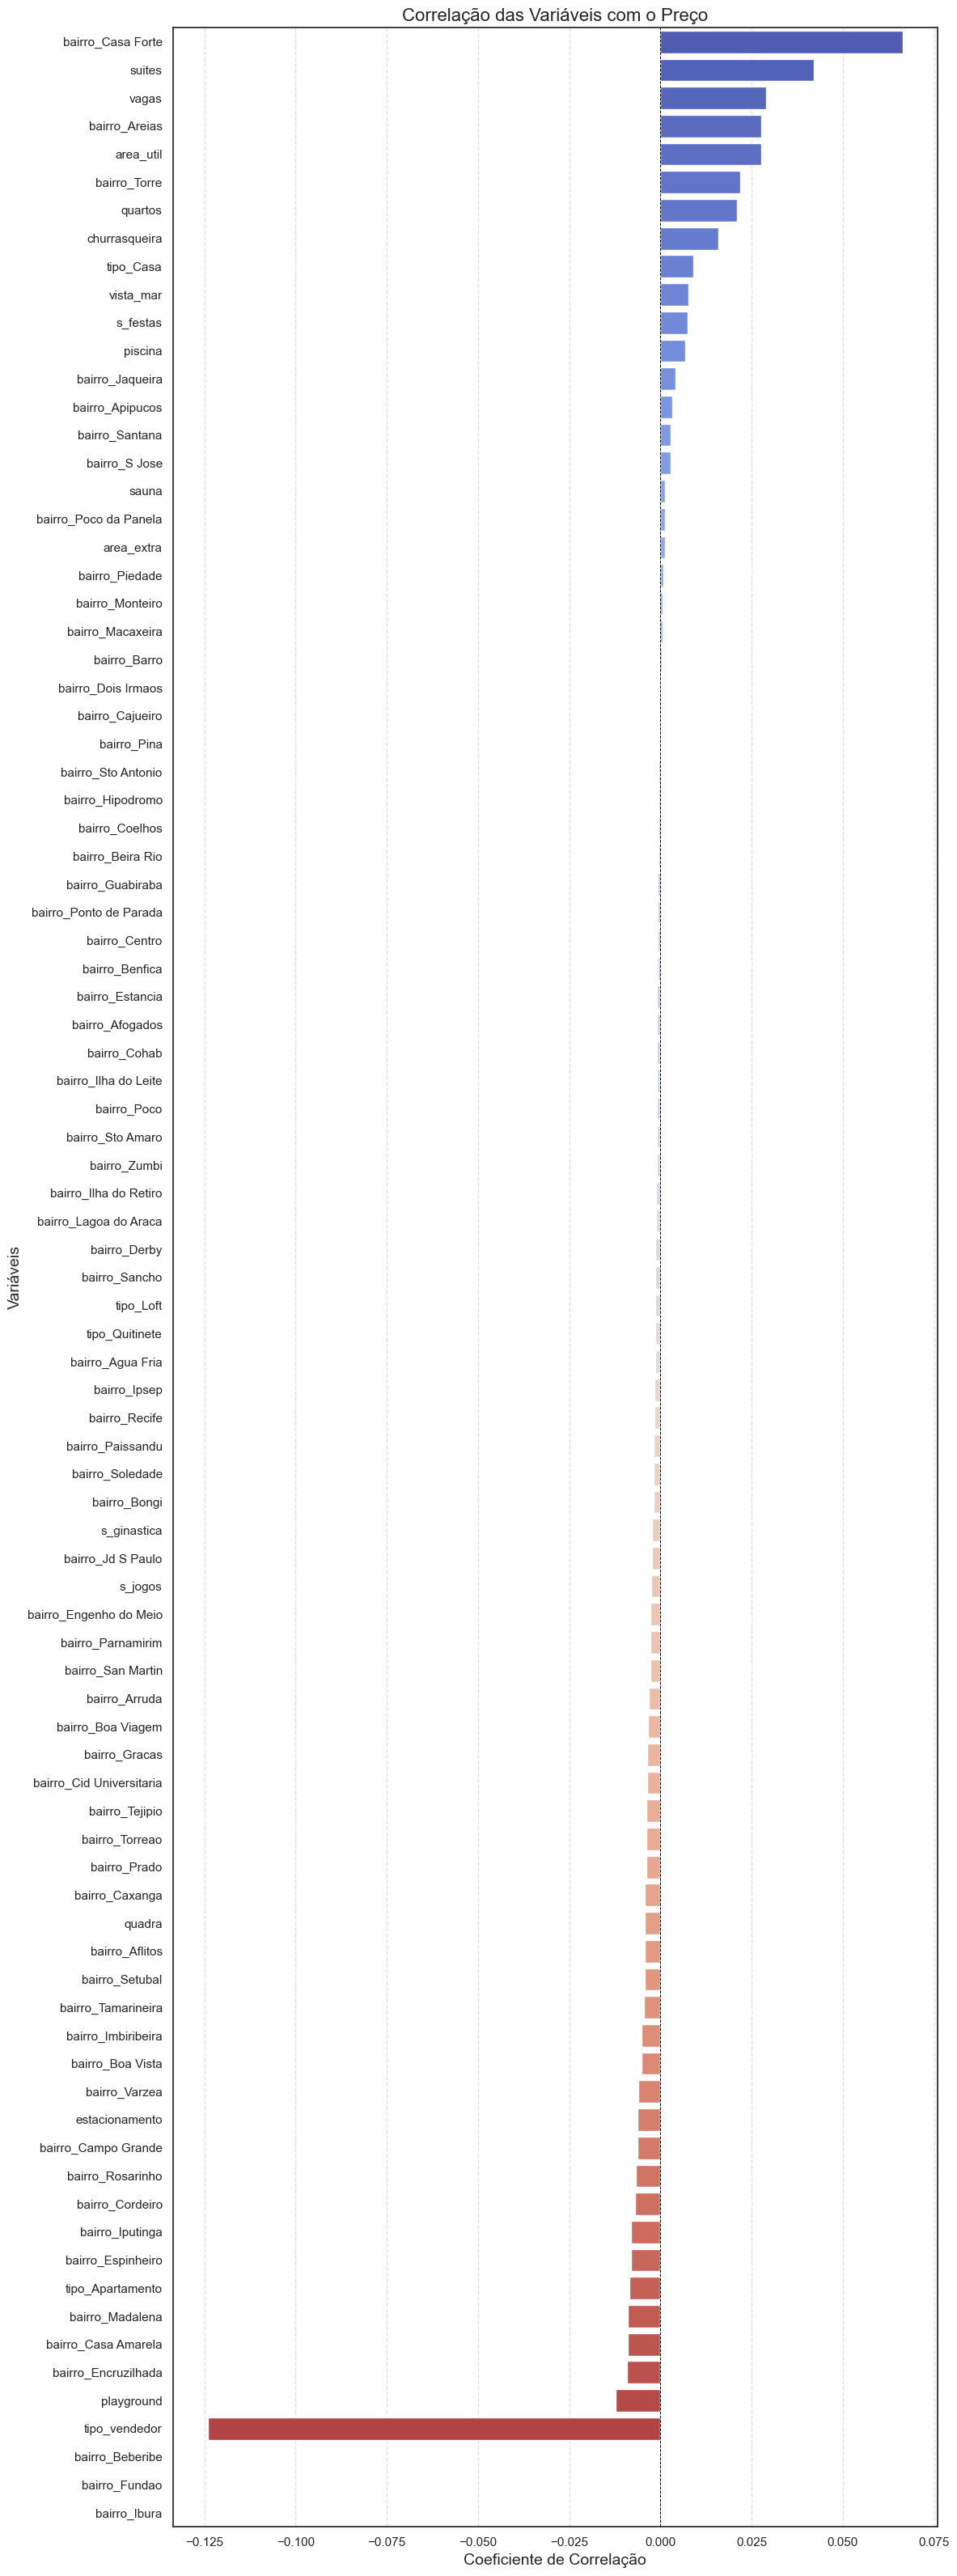

In [22]:
# Calcula a matriz de correlação e seleciona apenas as correlações com a coluna 'preco'
correlation_with_price = df.corr()['preco'].sort_values(ascending=False)

# Remove a correlação de 'preco' com ele mesmo (que é sempre 1) e exclui a coluna 'Id' se existir
columns_to_exclude = ['preco', 'Id']
correlation_with_price = correlation_with_price[~correlation_with_price.index.isin(columns_to_exclude)]

# Configura o gráfico de barras
plt.figure(figsize=(12, 32))
sns.barplot(x=correlation_with_price.values, y=correlation_with_price.index, palette='coolwarm')

# Adiciona rótulos e título
plt.title('Correlação das Variáveis com o Preço', fontsize=16)
plt.xlabel('Coeficiente de Correlação', fontsize=14)
plt.ylabel('Variáveis', fontsize=14)
plt.axvline(0, color='black', linestyle='--', linewidth=0.7)  # Linha indicando correlação nula

# Adiciona a grade
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()